In [43]:
from pathlib import Path
import sys

PROJECT_ROOT = Path.cwd()

# Nếu notebook đang chạy trong thư mục notebooks/
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent

sys.path.insert(0, str(PROJECT_ROOT))

print("Project root:", PROJECT_ROOT)

Project root: d:\Project_Intern\us-real-interest-rate-analysis


In [44]:
import os
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")
fred_api_key = os.getenv("FRED_API_KEY")

from matplotlib import dates as mdates
from matplotlib import pyplot as plt

from src.data_loader import load_interest_rate_data

from src.calculations import (
    build_analysis_dataset,
    get_data_status,
    get_latest_metrics,
)

In [45]:
# Lấy dữ liệu
raw_data = load_interest_rate_data(
    api_key=fred_api_key,
    start_date="2000-01-01",
)

nominal_df = raw_data["nominal_rate"]
expected_df = raw_data["expected_inflation"]

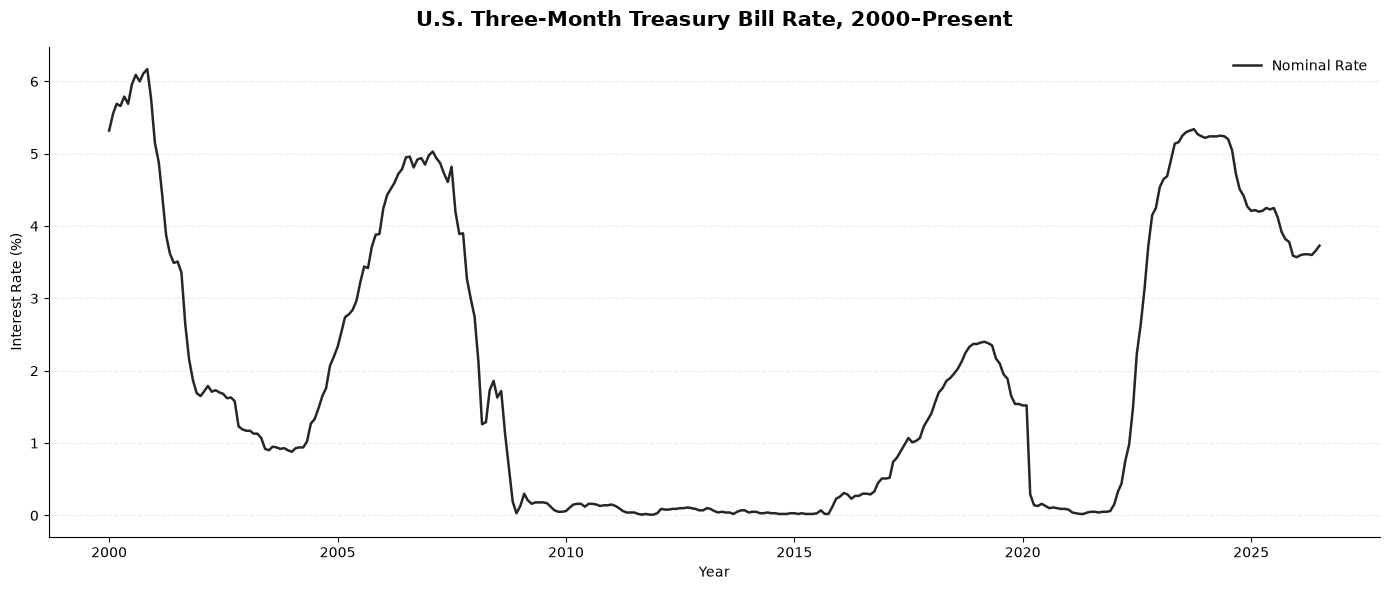

Figure saved to: D:\Project_Intern\us-real-interest-rate-analysis\outputs\tb3ms_nominal_rate.png


In [41]:
# Vẽ biểu đồ lãi suất danh nghĩa theo thời gian
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    nominal_df.index,
    nominal_df["nominal_rate"],
    color="#262626",
    linewidth=1.8,
    label="Nominal Rate"
)

ax.set_title(
    "U.S. Three-Month Treasury Bill Rate, 2000–Present",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Interest Rate (%)")

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()

output_directory = project_root / "outputs"
output_directory.mkdir(parents=True, exist_ok=True)

figure_file = output_directory / "tb3ms_nominal_rate.png"

fig.savefig(
    figure_file,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Figure saved to: {figure_file}")

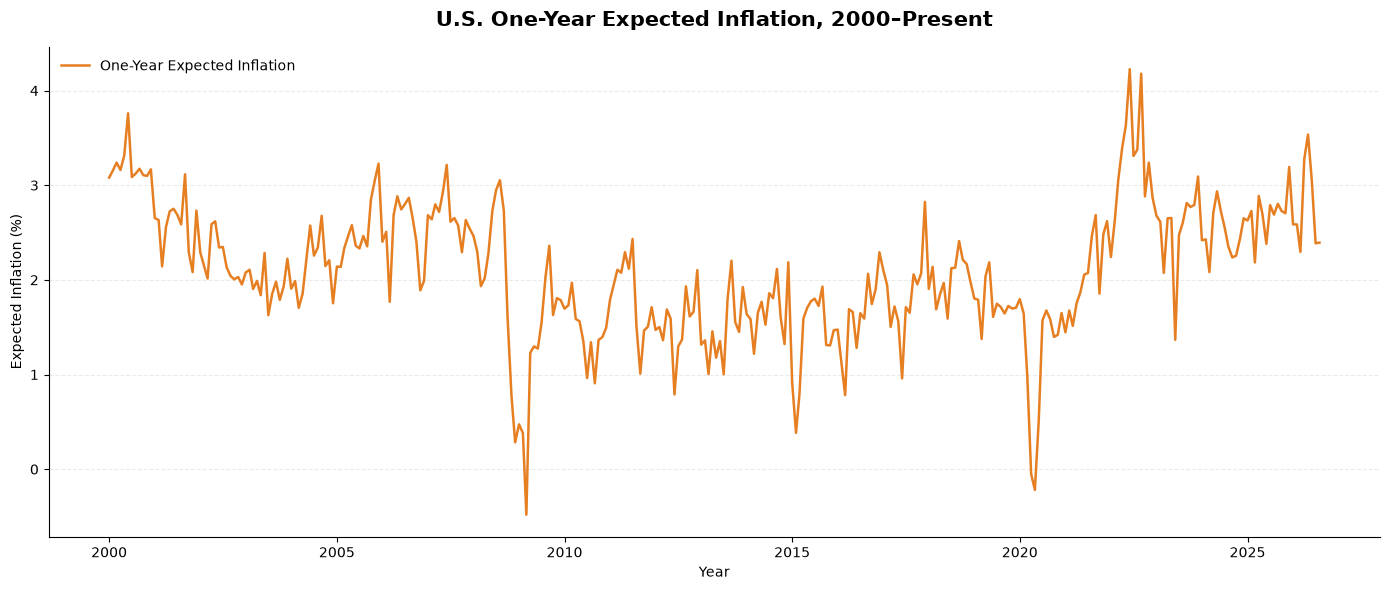

Figure saved to: D:\Project_Intern\us-real-interest-rate-analysis\outputs\expected_inflation.png


In [37]:
# Vẽ biểu đồ lạm phát kỳ vọng
fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    expected_df.index,
    expected_df["expected_inflation"],
    color="#E67E22",
    linewidth=1.8,
    label="One-Year Expected Inflation"
)

ax.set_title(
    "U.S. One-Year Expected Inflation, 2000–Present",
    fontsize=15,
    fontweight="bold",
    pad=15
)

ax.set_xlabel("Year")
ax.set_ylabel("Expected Inflation (%)")

ax.xaxis.set_major_locator(mdates.YearLocator(5))
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

ax.legend(frameon=False)

plt.tight_layout()

figure_file = output_directory / "expected_inflation.png"

fig.savefig(figure_file, dpi=300, bbox_inches="tight")

plt.show()
print(f"Figure saved to: {figure_file}")

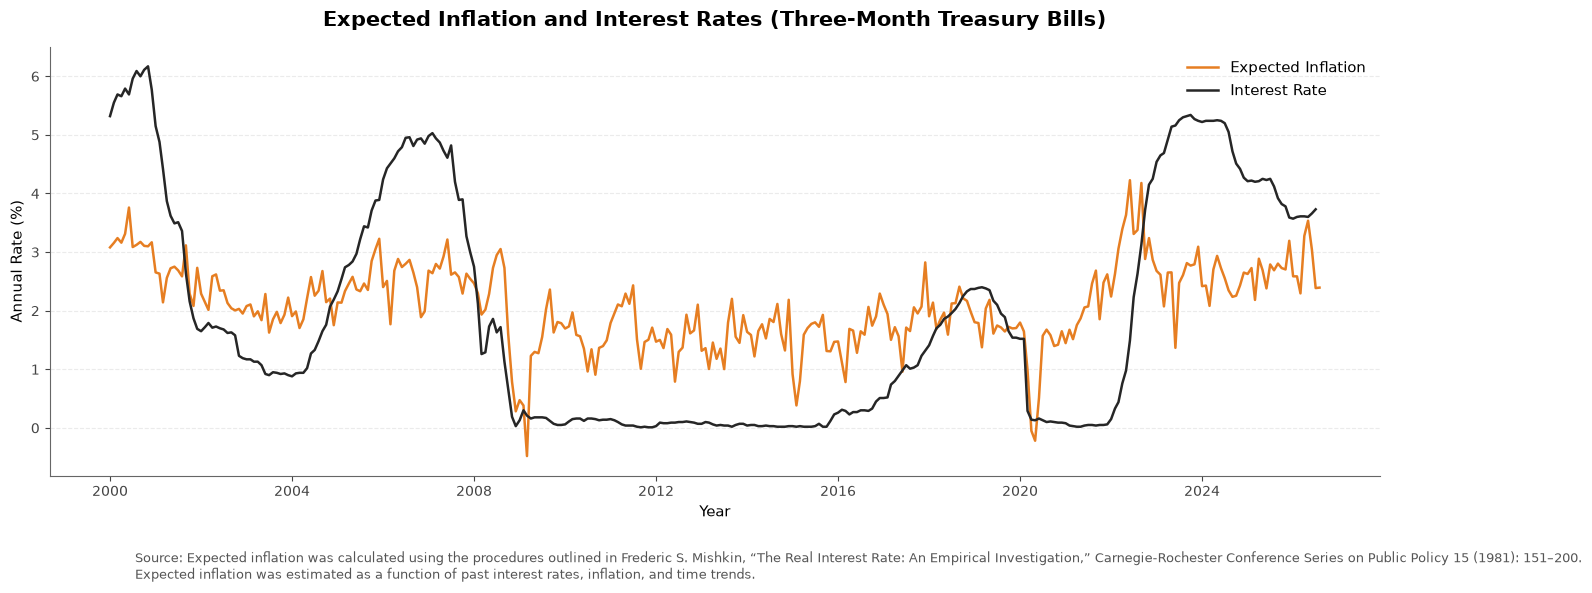

Figure saved to: D:\Project_Intern\us-real-interest-rate-analysis\outputs\nominal_and_expected_inflation.png


In [46]:
from matplotlib.pyplot import axis


fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(
    expected_df.index,
    expected_df["expected_inflation"],
    color="#E67E22",
    linewidth=1.8,
    label="Expected Inflation"
)
ax.plot(
    nominal_df.index,
    nominal_df["nominal_rate"],
    color="#262626",
    linewidth=1.8,
    label="Interest Rate"
)

ax.set_title(
    "Expected Inflation and Interest Rates (Three-Month Treasury Bills)",
    fontsize=15,
    fontweight="bold",
    pad=15
)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Annual Rate (%)", fontsize=11)

ax.grid(
    axis="y",
    linestyle="--",
    alpha=0.25
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#666666")
ax.spines["bottom"].set_color("#666666")
ax.tick_params(axis="both", colors="#444444")
ax.legend(loc="upper right", frameon=False, fontsize=11)

source_note = (
    "Source: Expected inflation was calculated using the procedures outlined in "
    'Frederic S. Mishkin, “The Real Interest Rate: An Empirical Investigation,” '
    "Carnegie-Rochester Conference Series on Public Policy 15 (1981): 151–200.\n"
    "Expected inflation was estimated as a function of past interest rates, "
    "inflation, and time trends."
)

fig.text(0.10, 0.02, source_note, ha="left", va="bottom", fontsize=9, color="#555555")

plt.tight_layout(rect=[0, 0.10, 1, 1])

main_figure_file = (output_directory / "nominal_and_expected_inflation.png")

fig.savefig(
    main_figure_file,
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

print(f"Figure saved to: {main_figure_file}")